# VISTA Br8667 benchmark: train / validation / gene plots

This notebook updates the older VISTA Br8667 notebook so it follows the frozen benchmark design.

## What changed from the old notebook

- Uses `spatial_train_210genes.h5ad` as the **only Xenium training input**.
- Uses `validation_truth_45genes.h5ad` only after training.
- Keeps the Huuki snRNA-seq reference complete.
- Runs VISTA training on the training genes.
- Predicts the 45 hidden validation genes.
- Calculates validation metrics.
- Creates observed-vs-predicted spatial gene plots.

The 45 blind-test genes are not loaded or evaluated here.


In [1]:
from pathlib import Path
import random
import time
import re
import gc
import importlib

# -----------------------------------------------------------------------------
# Patch VISTA train() validation-loader bug before importing GIMVI_GCN.
# -----------------------------------------------------------------------------
# Your local VISTA implementation always does:
#     val = ds.val_dataloader()
#     val_dls.append(val)
#     val.mode = i
#
# When validation_size=0.0, val is None, so this crashes with:
#     AttributeError: 'NoneType' object has no attribute 'mode'
#
# For this benchmark, we do not need VISTA's internal cell-level validation
# dataloader. Validation is done after training using 45 hidden genes.
VISTA_MODEL_FILE = (
    Path("/users/mjabin/projects/GeneBridge")
    / "src/imputation/VISTA/vista/_model.py"
)

if VISTA_MODEL_FILE.exists():
    text = VISTA_MODEL_FILE.read_text()

    old_block = (
        "            val = ds.val_dataloader()\n"
        "            val_dls.append(val)\n"
        "            val.mode = i"
    )

    new_block = (
        "            val = ds.val_dataloader()\n"
        "            if val is not None:\n"
        "                val_dls.append(val)\n"
        "                val.mode = i"
    )

    if old_block in text:
        backup_path = VISTA_MODEL_FILE.with_suffix(".py.before_vista_no_val_patch")
        backup_path.write_text(text)

        VISTA_MODEL_FILE.write_text(
            text.replace(old_block, new_block)
        )

        print("Patched VISTA source:")
        print(VISTA_MODEL_FILE)
        print("Backup saved:")
        print(backup_path)

    elif new_block in text:
        print("VISTA source is already patched:")
        print(VISTA_MODEL_FILE)

    else:
        print("WARNING: Could not find the exact VISTA validation-loader block.")
        print("Please inspect:")
        print(VISTA_MODEL_FILE)

else:
    print("WARNING: VISTA model file not found at:")
    print(VISTA_MODEL_FILE)


import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.stats as st
from scipy import sparse
from scipy.stats import pearsonr, spearmanr
import torch

# Import VISTA only after patching the source file.
from vista import GIMVI_GCN

SEED = 8667
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.set_float32_matmul_precision("high")

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


VISTA source is already patched:
/users/mjabin/projects/GeneBridge/src/imputation/VISTA/vista/_model.py


/scratch/mjabin/conda_envs/Imputation/lib/python3.9/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
Global seed set to 0


PyTorch: 2.1.2+cu118
CUDA available: False


/scratch/mjabin/conda_envs/Imputation/lib/python3.9/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
def _mean_expression(adata):
    """Return mean expression across observations as a one-dimensional array."""
    if sparse.issparse(adata.X):
        return np.asarray(adata.X.mean(axis=0)).ravel()
    return np.asarray(adata.X).mean(axis=0)


def calculate_pseudo_correlation(
    adata_sc,
    adata_st,
    celltype="scClassify",
    p_value_threshold=0.05,
    cor_threshold=0.5,
    exclude_types=("Other",),
):
    """Select measured spatial genes with consistent cell-type pseudobulk patterns."""

    if celltype not in adata_sc.obs:
        raise KeyError(f"{celltype!r} is missing from snRNA obs.")
    if celltype not in adata_st.obs:
        raise KeyError(f"{celltype!r} is missing from Xenium obs.")

    overlap_genes = sorted(set(adata_sc.var_names) & set(adata_st.var_names))
    if not overlap_genes:
        raise ValueError("No genes overlap between snRNA and Xenium.")

    sc_overlap = adata_sc[:, overlap_genes]
    st_overlap = adata_st[:, overlap_genes]

    sc_types = set(sc_overlap.obs[celltype].astype(str))
    st_types = set(st_overlap.obs[celltype].astype(str))
    common_types = sorted((sc_types & st_types) - set(exclude_types))

    print("Common cell types used:", common_types)

    if len(common_types) < 3:
        raise ValueError(
            "At least three common cell types are needed for Pearson correlation. "
            f"Found: {common_types}"
        )

    pseudo_sc = []
    pseudo_st = []

    for label in common_types:
        sc_subset = sc_overlap[sc_overlap.obs[celltype].astype(str) == label]
        st_subset = st_overlap[st_overlap.obs[celltype].astype(str) == label]

        if sc_subset.n_obs == 0 or st_subset.n_obs == 0:
            continue

        pseudo_sc.append(_mean_expression(sc_subset))
        pseudo_st.append(_mean_expression(st_subset))

    pseudo_sc = np.asarray(pseudo_sc)
    pseudo_st = np.asarray(pseudo_st)

    records = []
    for gene_index, gene in enumerate(overlap_genes):
        x = pseudo_sc[:, gene_index]
        y = pseudo_st[:, gene_index]

        if np.allclose(x, x[0]) or np.allclose(y, y[0]):
            correlation, pvalue = np.nan, np.nan
        else:
            correlation, pvalue = st.pearsonr(x, y)

        records.append((gene, correlation, pvalue))

    information = pd.DataFrame(
        records,
        columns=["gene", "pearson", "pvalue"],
    ).set_index("gene")

    selected = information.loc[
        (information["pvalue"] < p_value_threshold)
        & (information["pearson"] > cor_threshold)
    ]

    print("Measured overlapping genes:", len(overlap_genes))
    print("Genes retained for Xenium training:", selected.shape[0])

    return selected, information


def row_sums(matrix):
    if sparse.issparse(matrix):
        return np.asarray(matrix.sum(axis=1)).ravel()
    return np.asarray(matrix).sum(axis=1)


def to_dense_float32(matrix):
    if sparse.issparse(matrix):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=np.float32)


def safe_spearman(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if x.size < 3 or np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return np.nan

    result = spearmanr(x, y)
    return float(result.statistic if hasattr(result, "statistic") else result[0])


def safe_pearson(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if x.size < 3 or np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return np.nan

    result = pearsonr(x, y)
    return float(result.statistic if hasattr(result, "statistic") else result[0])


def zscore(values):
    values = np.asarray(values, dtype=np.float64)
    sd = np.std(values)

    if not np.isfinite(sd) or sd <= 1e-12:
        return np.full_like(values, np.nan, dtype=np.float64)

    return (values - np.mean(values)) / sd


def calculate_validation_gene_metrics(observed_raw, predicted_raw, genes):
    if observed_raw.shape != predicted_raw.shape:
        raise ValueError(
            f"Shape mismatch: observed={observed_raw.shape}, "
            f"predicted={predicted_raw.shape}"
        )

    observed_log = np.log1p(np.clip(observed_raw, 0, None))
    predicted_log = np.log1p(np.clip(predicted_raw, 0, None))

    records = []

    for gene_index, gene in enumerate(genes):
        obs = observed_raw[:, gene_index]
        pred = predicted_raw[:, gene_index]
        obs_log = observed_log[:, gene_index]
        pred_log = predicted_log[:, gene_index]

        obs_z = zscore(obs_log)
        pred_z = zscore(pred_log)
        valid_z = np.isfinite(obs_z) & np.isfinite(pred_z)

        if valid_z.any():
            mae_z = float(np.mean(np.abs(pred_z[valid_z] - obs_z[valid_z])))
            rmse_z = float(np.sqrt(np.mean((pred_z[valid_z] - obs_z[valid_z]) ** 2)))
        else:
            mae_z = np.nan
            rmse_z = np.nan

        records.append(
            {
                "gene": gene,
                "spearman_across_cells": safe_spearman(obs, pred),
                "pearson_log1p_across_cells": safe_pearson(obs_log, pred_log),
                "mae_log1p": float(np.mean(np.abs(pred_log - obs_log))),
                "rmse_log1p": float(np.sqrt(np.mean((pred_log - obs_log) ** 2))),
                "mae_standardized_log1p": mae_z,
                "rmse_standardized_log1p": rmse_z,
                "observed_mean": float(np.mean(obs)),
                "predicted_mean": float(np.mean(pred)),
                "observed_variance": float(np.var(obs)),
                "predicted_variance": float(np.var(pred)),
                "observed_nonzero_fraction": float(np.mean(obs > 0)),
                "predicted_positive_fraction": float(np.mean(pred > 0)),
            }
        )

    return pd.DataFrame(records)


def calculate_pseudobulk_metrics(observed_raw, predicted_raw, genes, obs_metadata, group_column):
    if group_column not in obs_metadata.columns:
        print(f"Skipping pseudobulk: {group_column!r} is absent.")
        return pd.DataFrame()

    groups = obs_metadata[group_column].astype(str).to_numpy()
    unique_groups = sorted(pd.unique(groups))

    observed_log = np.log1p(np.clip(observed_raw, 0, None))
    predicted_log = np.log1p(np.clip(predicted_raw, 0, None))

    records = []

    for gene_index, gene in enumerate(genes):
        obs_means = []
        pred_means = []
        kept_groups = []

        for group in unique_groups:
            mask = groups == group

            if int(mask.sum()) == 0:
                continue

            obs_means.append(float(observed_log[mask, gene_index].mean()))
            pred_means.append(float(predicted_log[mask, gene_index].mean()))
            kept_groups.append(group)

        records.append(
            {
                "gene": gene,
                "group_column": group_column,
                "n_groups": len(kept_groups),
                "groups": "|".join(kept_groups),
                "pseudobulk_spearman": safe_spearman(obs_means, pred_means),
                "pseudobulk_pearson_log1p": safe_pearson(obs_means, pred_means),
            }
        )

    return pd.DataFrame(records)


def first_existing_column(dataframe, candidates):
    return next((column for column in candidates if column in dataframe.columns), None)


def _scalar_to_float(value):
    if torch.is_tensor(value):
        value = value.detach().cpu()
        if value.numel() != 1:
            return np.nan
        return float(value.item())

    if isinstance(value, np.ndarray):
        if value.size != 1:
            return np.nan
        return float(value.reshape(-1)[0])

    if isinstance(value, (list, tuple)):
        if len(value) != 1:
            return np.nan
        return _scalar_to_float(value[0])

    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def history_to_series(history_value):
    if isinstance(history_value, pd.DataFrame):
        raw_values = history_value.to_numpy(dtype=object).reshape(-1)
    elif isinstance(history_value, pd.Series):
        raw_values = history_value.to_numpy(dtype=object).reshape(-1)
    else:
        raw_values = np.asarray(history_value, dtype=object).reshape(-1)

    numeric_values = [_scalar_to_float(value) for value in raw_values]
    numeric_values = [value for value in numeric_values if np.isfinite(value)]

    return pd.Series(
        numeric_values,
        index=np.arange(1, len(numeric_values) + 1),
        dtype=float,
    )


## 1. Configure paths and run mode

In [ ]:
PROJECT_ROOT = Path("/users/mjabin/projects/GeneBridge")
BASE = PROJECT_ROOT / "data/processed/imputation_beta/Br8667"

# Frozen benchmark inputs
SEQ_PATH = BASE / "seq_data_huuki_snrna_Br8667_vista.h5ad"
SPATIAL_TRAIN_PATH = BASE / "benchmark/inputs/spatial_train_210genes.h5ad"
VALIDATION_TRUTH_PATH = BASE / "benchmark/truth/validation_truth_45genes.h5ad"
VALIDATION_SPLIT_PATH = BASE / "benchmark/splits/validation_genes_45.csv"
DEVELOPMENT_CELL_IDS_PATH = BASE / "benchmark/splits/development_cell_ids.csv"

# Outputs
OUTPUT_ROOT = PROJECT_ROOT / "outputs/imputation_beta/Br8667"
REPORT_DIR = OUTPUT_ROOT / "validation/vista"
FIGURE_DIR = REPORT_DIR / "figures"
MODEL_ROOT = OUTPUT_ROOT / "models"
PREDICTION_DIR = BASE / "benchmark/predictions"

for directory in [REPORT_DIR, FIGURE_DIR, MODEL_ROOT, PREDICTION_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Run configuration
# -----------------------------------------------------------------------------
RUN_MODE = "full"  # "smoke" or "full"

SMOKE_EPOCHS = 2
FULL_EPOCHS = 200
MAX_EPOCHS = SMOKE_EPOCHS if RUN_MODE == "smoke" else FULL_EPOCHS

BATCH_SIZE = 128
# Do not create an internal cell-level validation loader.
# The benchmark validation is the 45 held-out Xenium genes after training.
TRAIN_SIZE = 1.0
VALIDATION_SIZE = 0.0

N_LATENT = 32
NEIGHBOR_SIZE = 20

# Keep True to match the old VISTA notebook behavior, but now filtering is done
# only using the 210 training genes.
USE_PSEUDOCORRELATION_FILTER = True
PSEUDO_COR_THRESHOLD = 0.5
PSEUDO_P_VALUE_THRESHOLD = 0.05
MIN_SELECTED_GENES = 10

# GPU policy
REQUIRE_GPU_FOR_FULL_RUN = True
USE_GPU = False if RUN_MODE == "smoke" else "cuda:0"

# Full matrix prediction is memory heavy because VISTA returns all reference genes.
# It is required here to extract the 45 validation-gene predictions.
PREDICT_VALIDATION_GENES = True

N_GENES_TO_PLOT = 4

# Fast validation mode:
# "validation_255" trains/decodes only the 210 training genes + 45 validation genes.
# This avoids generating a huge 66k × 28,907 prediction matrix.
#
# "full_reference" keeps all snRNA genes, but prediction is very slow and memory heavy.
#VISTA_REFERENCE_MODE = "validation_255"  # "validation_255" or "full_reference"
VISTA_REFERENCE_MODE = "full_reference"


RUN_SUFFIX = "_smoke" if RUN_MODE == "smoke" else ""

MODEL_DIR = MODEL_ROOT / f"vista_train210_model{RUN_SUFFIX}"
PREDICTION_PATH = PREDICTION_DIR / f"vista_validation_predictions_45genes{RUN_SUFFIX}.h5ad"

print("Run mode:", RUN_MODE)
print("Epochs:", MAX_EPOCHS)
print("Use GPU:", USE_GPU)
print("Model directory:", MODEL_DIR)
print("Prediction file:", PREDICTION_PATH)


Run mode: smoke
Epochs: 2
Use GPU: False
Model directory: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/models/vista_train210_model_smoke
Prediction file: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/vista_validation_predictions_45genes_smoke.h5ad


## 2. Load snRNA reference, Xenium training input, and validation truth

In [4]:
for path in [SEQ_PATH, SPATIAL_TRAIN_PATH, VALIDATION_TRUTH_PATH, VALIDATION_SPLIT_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

seq_data = sc.read_h5ad(SEQ_PATH)
spatial_train = sc.read_h5ad(SPATIAL_TRAIN_PATH)
validation_truth = sc.read_h5ad(VALIDATION_TRUTH_PATH)
validation_split = pd.read_csv(VALIDATION_SPLIT_PATH)

print("snRNA reference:")
print(seq_data)

print("\nXenium training input:")
print(spatial_train)

print("\nValidation truth:")
print(validation_truth)

print("\nValidation split:")
display(validation_split.head())


snRNA reference:
AnnData object with n_obs × n_vars = 9897 × 28907
    obs: 'Sample', 'Barcode', 'key', 'SAMPLE_ID', 'pos', 'BrNum', 'round', 'Position', 'age', 'sex', 'diagnosis', 'sum', 'detected', 'subsets_Mito_sum', 'subsets_Mito_detected', 'subsets_Mito_percent', 'total', 'high_mito', 'low_sum', 'low_detected', 'discard_auto', 'doubletScore', 'prelimCluster', 'collapsedCluster', 'kmeans', 'sizeFactor', 'cellType_broad_k', 'cellType_k', 'cellType_broad_hc', 'cellType_hc', 'cellType_layer', 'layer_annotation', 'scClassify_original', 'scClassify', 'names', 'batch'
    var: 'source', 'type', 'gene_id', 'gene_version', 'gene_name', 'gene_type', 'binomial_deviance', 'matched_gene_symbol', 'original_var_name', 'vista_gene_symbol'
    uns: 'Samples', 'X_name', 'cell_type_colors', 'cell_type_colors_broad', 'vista_expression_matrix'
    obsm: 'GLMPCA_approx', 'HARMONY', 'TSNE', 'UMAP'

Xenium training input:
AnnData object with n_obs × n_vars = 66164 × 210
    obs: 'cell_id', 'x_centroid', 

,gene,split,expression_stratum,expression_stratum_number,mean_expression,variance_expression,detected_cell_count,detection_fraction,log1p_mean_expression,log1p_variance_expression,mean_percentile,variance_percentile,detection_percentile,composite_expression_score
0,ALOX5AP,validation,S1_lowest,1,0.144401,0.414969,5036,0.076114,0.134881,0.347108,0.153333,0.180000,0.116667,0.150000
1,IGFBP6,validation,S1_lowest,1,0.138313,0.223517,7225,0.109198,0.129548,0.201729,0.143333,0.103333,0.183333,0.143333
2,LILRB4,validation,S1_lowest,1,0.101688,0.252306,3748,0.056647,0.096844,0.224987,0.083333,0.116667,0.076667,0.092222
3,NXPH4,validation,S1_lowest,1,0.042545,0.096205,1844,0.027870,0.041665,0.091854,0.030000,0.046667,0.030000,0.035556
4,SMIM32,validation,S1_lowest,1,0.059594,0.476843,1684,0.025452,0.057886,0.389907,0.046667,0.203333,0.026667,0.092222


## 3. Validate benchmark split and align cells

In [5]:
train_genes = spatial_train.var_names.astype(str).tolist()
validation_genes = validation_truth.var_names.astype(str).tolist()
seq_gene_set = set(seq_data.var_names.astype(str))

checks = {
    "training_gene_count_is_210": len(train_genes) == 210,
    "validation_gene_count_is_45": len(validation_genes) == 45,
    "train_validation_disjoint": set(train_genes).isdisjoint(validation_genes),
    "all_training_genes_in_snrna": set(train_genes).issubset(seq_gene_set),
    "all_validation_genes_in_snrna": set(validation_genes).issubset(seq_gene_set),
    "spatial_validation_cells_match": spatial_train.obs_names.equals(validation_truth.obs_names),
    "spatial_coordinates_present": "spatial" in spatial_train.obsm,
}

print("Benchmark checks:")
for name, passed in checks.items():
    print(f"  {name}: {passed}")

if not all(checks.values()):
    failed = [name for name, passed in checks.items() if not passed]
    raise ValueError(f"Benchmark checks failed: {failed}")

# Use the same development-cell list as gimVI/SpaGE/Tangram when available.
if DEVELOPMENT_CELL_IDS_PATH.exists():
    development_cell_ids = (
        pd.read_csv(DEVELOPMENT_CELL_IDS_PATH)["cell_id"].astype(str).tolist()
    )

    missing = pd.Index(development_cell_ids).difference(spatial_train.obs_names.astype(str))

    if len(missing) > 0:
        raise ValueError(f"{len(missing)} development cells are missing from spatial_train.")

    spatial_train = spatial_train[development_cell_ids].copy()
    validation_truth = validation_truth[development_cell_ids].copy()

    print("Reused development-cell list:", len(development_cell_ids))

else:
    spatial_totals = row_sums(spatial_train.X)
    keep = spatial_totals > 0
    development_cell_ids = spatial_train.obs_names[keep].astype(str).tolist()

    spatial_train = spatial_train[development_cell_ids].copy()
    validation_truth = validation_truth[development_cell_ids].copy()

    pd.DataFrame({"cell_id": development_cell_ids}).to_csv(
        DEVELOPMENT_CELL_IDS_PATH,
        index=False,
    )

    print("Created development-cell list:", len(development_cell_ids))

assert spatial_train.obs_names.equals(validation_truth.obs_names)

print("Aligned spatial cells:", spatial_train.n_obs)
print("snRNA:", seq_data.shape)
print("spatial_train:", spatial_train.shape)
print("validation_truth:", validation_truth.shape)


Benchmark checks:
  training_gene_count_is_210: True
  validation_gene_count_is_45: True
  train_validation_disjoint: True
  all_training_genes_in_snrna: True
  all_validation_genes_in_snrna: True
  spatial_validation_cells_match: True
  spatial_coordinates_present: True
Reused development-cell list: 66154
Aligned spatial cells: 66154
snRNA: (9897, 28907)
spatial_train: (66154, 210)
validation_truth: (66154, 45)


## 4. Validate metadata and spatial coordinates

In [6]:
required_seq_obs = {"scClassify"}
required_spatial_obs = {"scClassify", "batch"}

missing_seq = required_seq_obs - set(seq_data.obs.columns)
missing_spatial = required_spatial_obs - set(spatial_train.obs.columns)

if missing_seq:
    raise KeyError(f"Missing snRNA obs columns: {sorted(missing_seq)}")
if missing_spatial:
    raise KeyError(f"Missing Xenium obs columns: {sorted(missing_spatial)}")

if "names" not in seq_data.obs.columns:
    seq_data.obs["names"] = seq_data.obs_names.astype(str)

if "names" not in spatial_train.obs.columns:
    spatial_train.obs["names"] = spatial_train.obs_names.astype(str)

seq_data.obs["ind_x"] = seq_data.obs_names.astype(str)
spatial_train.obs["ind_x"] = spatial_train.obs_names.astype(str)

spatial_coordinates = np.asarray(spatial_train.obsm["spatial"], dtype=np.float32)
if spatial_coordinates.shape != (spatial_train.n_obs, 2):
    raise ValueError(f"Unexpected spatial coordinate shape: {spatial_coordinates.shape}")

spatial_train.obsm["spatial"] = spatial_coordinates
validation_truth.obsm["spatial"] = spatial_coordinates.copy()

print("Metadata and spatial coordinates validated.")
print("snRNA scClassify counts:")
print(seq_data.obs["scClassify"].astype(str).value_counts())

print("\nXenium scClassify counts:")
print(spatial_train.obs["scClassify"].astype(str).value_counts())


Metadata and spatial coordinates validated.
snRNA scClassify counts:
Oligo        5305
Excit        2613
Other        1214
Inhib         340
Astro         250
EndoMural     114
OPC            61
Name: scClassify, dtype: int64

Xenium scClassify counts:
Oligo        14691
EndoMural    13821
Excit        13268
Astro         9247
Inhib         6702
Micro         4577
Other         3848
Name: scClassify, dtype: int64


## 5. Select VISTA spatial-input genes

The old notebook selected genes using pseudocorrelation across cell types.  
Here this filtering is performed **only on the 210 training genes**, never on the 45 validation genes.

Set `USE_PSEUDOCORRELATION_FILTER=False` to train VISTA on all 210 training genes.


In [7]:
if USE_PSEUDOCORRELATION_FILTER:
    selected_gene_table, all_gene_statistics = calculate_pseudo_correlation(
        seq_data,
        spatial_train,
        celltype="scClassify",
        p_value_threshold=PSEUDO_P_VALUE_THRESHOLD,
        cor_threshold=PSEUDO_COR_THRESHOLD,
        exclude_types=("Other",),
    )

    all_gene_statistics.to_csv(
        REPORT_DIR / f"12_vista_pseudocorrelation_all_training_genes{RUN_SUFFIX}.csv"
    )
    selected_gene_table.to_csv(
        REPORT_DIR / f"12_vista_pseudocorrelation_selected_genes{RUN_SUFFIX}.csv"
    )

    info_genes = selected_gene_table.index.astype(str).tolist()

    if len(info_genes) < MIN_SELECTED_GENES:
        raise ValueError(
            f"Only {len(info_genes)} genes passed pseudocorrelation filtering. "
            "Set USE_PSEUDOCORRELATION_FILTER=False or relax thresholds deliberately."
        )

else:
    all_gene_statistics = pd.DataFrame(index=train_genes)
    selected_gene_table = pd.DataFrame(index=train_genes)
    info_genes = train_genes.copy()

print("Available frozen training genes:", len(train_genes))
print("VISTA spatial-input genes:", len(info_genes))
print("First 20 VISTA input genes:")
print(info_genes[:20])

# Leakage guard
if not set(info_genes).issubset(set(train_genes)):
    raise ValueError("info_genes contains genes outside the frozen 210 training genes.")

if set(info_genes) & set(validation_genes):
    raise ValueError("Validation genes leaked into VISTA spatial input.")


Common cell types used: ['Astro', 'EndoMural', 'Excit', 'Inhib', 'Oligo']
Measured overlapping genes: 210
Genes retained for Xenium training: 138
Available frozen training genes: 210
VISTA spatial-input genes: 138
First 20 VISTA input genes:
['A2M', 'ABCG2', 'ACO1', 'ADCYAP1R1', 'ADIRF', 'AJ009632.2', 'AK5', 'AKAP8L', 'ANLN', 'APOLD1', 'AQP4', 'ARPC1B', 'ARPP19', 'ARRDC3', 'BAIAP3', 'BDNF', 'C1QL2', 'CABP1', 'CAMK2N1', 'CARTPT']


## 6. Build VISTA model inputs

In [8]:
if VISTA_REFERENCE_MODE == "validation_255":
    # Fast benchmark mode.
    # For validation, VISTA only needs to decode the 45 held-out genes.
    # Keeping all 28,907 snRNA genes makes get_imputed_values() return a huge
    # cells × genes matrix, which is slow and memory-heavy.
    gene_for_impute = list(
        dict.fromkeys(
            train_genes + validation_genes
        )
    )

elif VISTA_REFERENCE_MODE == "full_reference":
    # Full transcriptome mode.
    # This is appropriate for production imputation, but validation prediction
    # will be much slower because VISTA returns all snRNA genes.
    gene_for_impute = seq_data.var_names.astype(str).tolist()

else:
    raise ValueError(
        "VISTA_REFERENCE_MODE must be 'validation_255' or 'full_reference'."
    )

seq_data_model = seq_data[:, gene_for_impute].copy()
spatial_data_model = spatial_train[:, info_genes].copy()

print("VISTA reference mode:", VISTA_REFERENCE_MODE)
print("snRNA model input:", seq_data_model.shape)
print("Xenium model input:", spatial_data_model.shape)
print(
    "Xenium model genes subset of snRNA:",
    set(spatial_data_model.var_names) <= set(seq_data_model.var_names),
)

for gene in validation_genes:
    if gene not in seq_data_model.var_names:
        raise ValueError(
            f"Validation gene missing from VISTA reference model: {gene}"
        )

# Validate cell order with validation truth.
assert spatial_data_model.obs_names.equals(validation_truth.obs_names)


VISTA reference mode: validation_255
snRNA model input: (9897, 255)
Xenium model input: (66154, 138)
Xenium model genes subset of snRNA: True


## 7. Register AnnData for VISTA

In [9]:
GIMVI_GCN.setup_anndata(
    spatial_data_model,
    batch_key="batch",
    obs_names="names",
)

GIMVI_GCN.setup_anndata(seq_data_model)

print("VISTA AnnData setup complete.")


VISTA AnnData setup complete.


/scratch/mjabin/conda_envs/Imputation/lib/python3.9/site-packages/scvi/data/_utils.py:172: UserWarning: Category 0 in adata.obs['_scvi_ind_x'] has fewer than 3 cells. Models may not train properly.
  warnings.warn(


## 8. Construct VISTA model

In [10]:
model = GIMVI_GCN(
    seq_data_model,
    spatial_data_model,
    n_latent=N_LATENT,
    neighbor_size=NEIGHBOR_SIZE,
)

print(model)


/scratch/mjabin/conda_envs/Imputation/lib/python3.9/site-packages/scvi/model/_utils.py:286: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  warnings.warn(


GimVI Model with the following params: 
n_latent: 32, n_inputs: [255, 138], n_genes: 255, n_batch: 2, generative distributions: ['zinb', 'nb']
Training status: Not Trained
Model's adata is minified?: False

## 9. Train VISTA

In [11]:
if RUN_MODE == "full" and REQUIRE_GPU_FOR_FULL_RUN and not torch.cuda.is_available():
    raise RuntimeError(
        "Full VISTA training requires a visible GPU, but torch.cuda.is_available() is False."
    )

print("Training configuration:")
print("  mode:", RUN_MODE)
print("  epochs:", MAX_EPOCHS)
print("  use_gpu:", USE_GPU)
print("  batch size:", BATCH_SIZE)
print("  cell train size:", TRAIN_SIZE)
print("  cell validation size:", VALIDATION_SIZE)
print("  n_latent:", N_LATENT)
print("  neighbor_size:", NEIGHBOR_SIZE)
print("  VISTA input genes:", len(info_genes))

training_start = time.time()

# Important:
# VISTA can fail inside its internal validation dataloader with
# "negative column index found". We do not need internal cell-level
# validation here because our benchmark validation is the 45 hidden genes.
# Therefore, train on all available spatial cells and evaluate afterward.
model.train(
    max_epochs=MAX_EPOCHS,
    train_size=TRAIN_SIZE,
    validation_size=VALIDATION_SIZE,
    use_gpu=USE_GPU,
    batch_size=BATCH_SIZE,
)

training_seconds = time.time() - training_start

print(f"Training complete in {training_seconds / 60:.2f} minutes.")
print("Model trained:", model.is_trained if hasattr(model, "is_trained") else "unknown")
print("Model device:", model.device if hasattr(model, "device") else "unknown")


/scratch/mjabin/conda_envs/Imputation/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /scratch/mjabin/conda_envs/Imputation/lib/python3.9/ ...
  rank_zero_warn(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs


Training configuration:
  mode: smoke
  epochs: 2
  use_gpu: False
  batch size: 128
  cell train size: 1.0
  cell validation size: 0.0
  n_latent: 32
  neighbor_size: 20
  VISTA input genes: 138


/scratch/mjabin/conda_envs/Imputation/lib/python3.9/site-packages/lightning_fabric/plugins/environments/slurm.py:165: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /scratch/mjabin/conda_envs/Imputation/lib/python3.9/ ...
  rank_zero_warn(
/scratch/mjabin/conda_envs/Imputation/lib/python3.9/site-packages/pytorch_lightning/trainer/configuration_validator.py:108: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(


Epoch 2/2: 100%|██████████| 2/2 [00:42<00:00, 21.24s/it, loss=102, v_num=1]

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 2/2: 100%|██████████| 2/2 [00:42<00:00, 21.47s/it, loss=102, v_num=1]
Training complete in 0.72 minutes.
Model trained: True
Model device: cpu


## 10. Plot VISTA training-history curves

In [12]:
LOSS_CURVE_DIR = REPORT_DIR / "training_curves"
LOSS_CURVE_DIR.mkdir(parents=True, exist_ok=True)

history = getattr(model, "history", None)

if history is None or len(history) == 0:
    print("No model.history found. Skipping training-history plots.")
else:
    parsed_history = {}

    print("Available model.history metrics:")

    for metric_name, history_value in history.items():
        series = history_to_series(history_value)

        if len(series) == 0:
            print(f"  {metric_name}: skipped; no numeric values")
            continue

        parsed_history[metric_name] = series
        print(f"  {metric_name}: {len(series)} recorded values")

    history_tables = []

    for metric_name, series in parsed_history.items():
        history_tables.append(
            pd.DataFrame(
                {
                    "epoch": series.index,
                    "metric": metric_name,
                    "value": series.values,
                }
            )
        )

    if history_tables:
        history_table = pd.concat(history_tables, ignore_index=True)
        HISTORY_CSV_PATH = LOSS_CURVE_DIR / f"12_vista_training_history{RUN_SUFFIX}.csv"
        history_table.to_csv(HISTORY_CSV_PATH, index=False)

        created_history_figures = []

        for metric_name, series in parsed_history.items():
            readable_name = metric_name.replace("_", " ")

            plt.figure(figsize=(8, 5))
            plt.plot(series.index, series.values, linewidth=2)
            plt.xlabel("Recorded epoch")
            plt.ylabel(readable_name)
            plt.title(f"VISTA {readable_name}")
            plt.grid(alpha=0.25)
            plt.tight_layout()

            safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", metric_name)
            figure_path = LOSS_CURVE_DIR / f"12_vista_{safe_name}{RUN_SUFFIX}.png"

            plt.savefig(figure_path, dpi=220, bbox_inches="tight")
            plt.show()
            plt.close()

            created_history_figures.append(figure_path)

        print("Saved history CSV:", HISTORY_CSV_PATH)
        print("Created history figures:")
        for path in created_history_figures:
            print(path)


No model.history found. Skipping training-history plots.


## 11. Save trained VISTA model

In [13]:
model.save(
    str(MODEL_DIR),
    overwrite=True,
    save_anndata=False,
)

run_metadata = pd.DataFrame(
    [
        {"field": "run_mode", "value": RUN_MODE},
        {"field": "vista_reference_mode", "value": VISTA_REFERENCE_MODE},
        {"field": "epochs", "value": MAX_EPOCHS},
        {"field": "batch_size", "value": BATCH_SIZE},
        {"field": "train_size", "value": TRAIN_SIZE},
        {"field": "validation_size", "value": VALIDATION_SIZE},
        {"field": "n_latent", "value": N_LATENT},
        {"field": "neighbor_size", "value": NEIGHBOR_SIZE},
        {"field": "use_pseudocorrelation_filter", "value": USE_PSEUDOCORRELATION_FILTER},
        {"field": "frozen_training_genes", "value": len(train_genes)},
        {"field": "vista_spatial_input_genes", "value": len(info_genes)},
        {"field": "validation_genes", "value": len(validation_genes)},
        {"field": "spatial_cells", "value": spatial_data_model.n_obs},
        {"field": "snrna_nuclei", "value": seq_data_model.n_obs},
        {"field": "training_seconds", "value": training_seconds},
    ]
)

RUN_METADATA_PATH = REPORT_DIR / f"12_vista_run_metadata{RUN_SUFFIX}.csv"
run_metadata.to_csv(RUN_METADATA_PATH, index=False)

print("Saved model:", MODEL_DIR)
print("Saved run metadata:", RUN_METADATA_PATH)


Saved model: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/models/vista_train210_model_smoke
Saved run metadata: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/12_vista_run_metadata_smoke.csv


## 12. Predict the 45 validation genes

VISTA's public API returns predictions for every gene in `seq_data_model`.

In fast validation mode, `seq_data_model` contains only:

```text
210 training genes + 45 validation genes = 255 genes
```

So prediction is much faster than decoding the full 28,907-gene reference.


In [14]:
if PREDICT_VALIDATION_GENES:
    validation_positions = seq_data_model.var_names.astype(str).get_indexer(validation_genes)

    if np.any(validation_positions < 0):
        missing = [
            validation_genes[index]
            for index, position in enumerate(validation_positions)
            if position < 0
        ]
        raise ValueError(f"Validation genes missing from snRNA model reference: {missing[:20]}")

    prediction_start = time.time()

    # Existing VISTA API returns a full cells × reference-genes matrix.
    full_spatial_prediction = model.get_imputed_values(
        normalized=False,
        batch_size=BATCH_SIZE,
    )[0].astype(np.float32, copy=False)

    prediction_seconds = time.time() - prediction_start

    expected_shape = (spatial_data_model.n_obs, seq_data_model.n_vars)
    if full_spatial_prediction.shape != expected_shape:
        raise ValueError(
            f"Unexpected full prediction shape: {full_spatial_prediction.shape}; "
            f"expected {expected_shape}"
        )

    validation_prediction = full_spatial_prediction[:, validation_positions].astype(
        np.float32,
        copy=False,
    )

    del full_spatial_prediction
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Validation prediction shape:", validation_prediction.shape)
    print(f"Prediction completed in {prediction_seconds / 60:.2f} minutes.")

    if not np.isfinite(validation_prediction).all():
        raise ValueError("Validation predictions contain NaN or infinity.")

    if np.any(validation_prediction < 0):
        raise ValueError("Validation predictions contain negative values.")

    print("All-zero predicted cells:", int(np.sum(validation_prediction.sum(axis=1) == 0)))
    print("All-zero predicted validation genes:", int(np.sum(validation_prediction.sum(axis=0) == 0)))

else:
    print("PREDICT_VALIDATION_GENES=False; skipping validation prediction.")


Validation prediction shape: (66154, 45)
Prediction completed in 0.01 minutes.
All-zero predicted cells: 50
All-zero predicted validation genes: 0


## 13. Save VISTA validation predictions

In [15]:
prediction_adata = ad.AnnData(
    X=validation_prediction.astype(np.float32, copy=False),
    obs=spatial_data_model.obs.copy(),
    var=validation_truth[:, validation_genes].var.copy(),
)

prediction_adata.obsm["spatial"] = spatial_data_model.obsm["spatial"].copy()

prediction_adata.uns["method"] = "VISTA"
prediction_adata.uns["benchmark_role"] = "validation_prediction"
prediction_adata.uns["run_mode"] = RUN_MODE
prediction_adata.uns["vista_reference_mode"] = VISTA_REFERENCE_MODE
prediction_adata.uns["normalized_predictions"] = False
prediction_adata.uns["frozen_training_genes"] = int(len(train_genes))
prediction_adata.uns["vista_spatial_input_genes"] = int(len(info_genes))
prediction_adata.uns["validation_genes"] = int(len(validation_genes))
prediction_adata.uns["n_latent"] = int(N_LATENT)
prediction_adata.uns["neighbor_size"] = int(NEIGHBOR_SIZE)

prediction_adata.write_h5ad(PREDICTION_PATH, compression="gzip")

print("Saved validation predictions:", PREDICTION_PATH)
print("Prediction file size MB:", PREDICTION_PATH.stat().st_size / (1024 ** 2))


Saved validation predictions: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/vista_validation_predictions_45genes_smoke.h5ad
Prediction file size MB: 28.43660831451416


## 14. Evaluate the 45 hidden validation genes

In [16]:
observed_validation = to_dense_float32(validation_truth[:, validation_genes].X)

gene_metrics = calculate_validation_gene_metrics(
    observed_raw=observed_validation,
    predicted_raw=validation_prediction,
    genes=validation_genes,
)

merge_columns = [
    column
    for column in [
        "gene",
        "expression_stratum",
        "expression_stratum_number",
        "mean_expression",
        "detection_fraction",
    ]
    if column in validation_split.columns
]

if merge_columns:
    gene_metrics = gene_metrics.merge(
        validation_split[merge_columns],
        on="gene",
        how="left",
    )

GENE_METRICS_PATH = REPORT_DIR / f"13_vista_validation_gene_metrics{RUN_SUFFIX}.csv"
SUMMARY_PATH = REPORT_DIR / f"13_vista_validation_summary{RUN_SUFFIX}.csv"

gene_metrics.to_csv(GENE_METRICS_PATH, index=False)

summary = pd.DataFrame(
    [
        {"metric": "run_mode", "value": RUN_MODE},
        {"metric": "n_validation_genes", "value": len(validation_genes)},
        {"metric": "spatial_cells", "value": spatial_data_model.n_obs},
        {"metric": "vista_spatial_input_genes", "value": len(info_genes)},
        {
            "metric": "median_spearman_across_genes",
            "value": gene_metrics["spearman_across_cells"].median(skipna=True),
        },
        {
            "metric": "median_pearson_log1p_across_genes",
            "value": gene_metrics["pearson_log1p_across_cells"].median(skipna=True),
        },
        {
            "metric": "median_mae_log1p_across_genes",
            "value": gene_metrics["mae_log1p"].median(skipna=True),
        },
        {
            "metric": "median_rmse_log1p_across_genes",
            "value": gene_metrics["rmse_log1p"].median(skipna=True),
        },
        {
            "metric": "all_zero_predicted_cells",
            "value": int(np.sum(validation_prediction.sum(axis=1) == 0)),
        },
        {
            "metric": "all_zero_predicted_genes",
            "value": int(np.sum(validation_prediction.sum(axis=0) == 0)),
        },
        {"metric": "training_seconds", "value": training_seconds},
        {"metric": "prediction_seconds", "value": prediction_seconds},
    ]
)

summary.to_csv(SUMMARY_PATH, index=False)

print("Validation summary:")
display(summary)

print("\nTop validation genes:")
display(gene_metrics.sort_values("spearman_across_cells", ascending=False).head(10))

print("\nLowest validation genes:")
display(gene_metrics.sort_values("spearman_across_cells", ascending=True).head(10))

print("\nSaved:")
print(GENE_METRICS_PATH)
print(SUMMARY_PATH)


Validation summary:


,metric,value
0,run_mode,smoke
1,n_validation_genes,45
2,spatial_cells,66154
3,vista_spatial_input_genes,138
4,median_spearman_across_genes,0.364279
5,median_pearson_log1p_across_genes,0.395811
6,median_mae_log1p_across_genes,0.398045
7,median_rmse_log1p_across_genes,0.5444
8,all_zero_predicted_cells,50
9,all_zero_predicted_genes,0



Top validation genes:


,gene,spearman_across_cells,pearson_log1p_across_cells,mae_log1p,rmse_log1p,mae_standardized_log1p,rmse_standardized_log1p,observed_mean,predicted_mean,observed_variance,predicted_variance,observed_nonzero_fraction,predicted_positive_fraction,expression_stratum,expression_stratum_number,mean_expression,detection_fraction
21,KIF1A,0.852520,0.839672,0.444000,0.544400,0.456399,0.566266,5.835263,4.540455,40.272491,29.105227,0.833222,0.999244,S5_highest,5,5.834047,0.833097
15,ENC1,0.829985,0.857904,0.536086,0.679651,0.406384,0.533097,8.161396,7.064843,220.017807,101.401993,0.681561,0.999244,S5_highest,5,8.160025,0.681458
31,OGA,0.808534,0.813023,0.571236,0.674966,0.489162,0.611518,5.153913,2.376143,34.229481,5.868444,0.845164,0.999244,S5_highest,5,5.152765,0.845037
33,PSMA7,0.744503,0.755027,0.570767,0.684364,0.562945,0.699961,3.077214,1.212103,10.824978,1.646531,0.793799,0.999244,S5_highest,5,3.076810,0.793679
12,CSMD1,0.743602,0.775235,1.969689,2.082086,0.543714,0.670470,3.482208,24.702583,41.000420,684.227783,0.489404,0.999244,S5_highest,5,3.481564,0.489330
10,CHST1,0.705194,0.735205,0.507314,0.692733,0.539601,0.727729,2.071198,0.613282,11.627937,0.590352,0.518124,0.999244,S4_high,4,2.071097,0.518046
24,MBP,0.699297,0.725671,0.746076,0.924017,0.582512,0.740714,5.196209,10.276532,43.041801,163.116547,0.801690,0.999244,S5_highest,5,5.195215,0.801569
27,MT-ND4,0.686123,0.706258,1.171687,1.366748,0.589201,0.766476,61.346901,23.282425,1495.842407,468.161713,0.996266,0.999244,S5_highest,5,61.337800,0.996116
14,EGR3,0.655456,0.740925,0.440873,0.625390,0.528781,0.719826,1.594129,0.489347,11.233431,0.279535,0.413656,0.999244,S4_high,4,1.594090,0.413593
18,GRIN2A,0.653781,0.703536,1.550513,1.728103,0.599106,0.770018,0.672884,10.560972,2.346544,212.527908,0.272168,0.999244,S3_medium,3,0.672800,0.272127



Lowest validation genes:


,gene,spearman_across_cells,pearson_log1p_across_cells,mae_log1p,rmse_log1p,mae_standardized_log1p,rmse_standardized_log1p,observed_mean,predicted_mean,observed_variance,predicted_variance,observed_nonzero_fraction,predicted_positive_fraction,expression_stratum,expression_stratum_number,mean_expression,detection_fraction
28,MTRNR2L12,-0.041141,-0.030035,1.950830,2.226553,1.147768,1.435294,47.491989,7.161026,1099.114502,48.540241,0.998005,0.999244,S5_highest,5,47.485172,0.997990
41,THEMIS,0.065785,0.068926,0.649033,0.760845,0.928081,1.364605,0.021389,1.106843,0.024137,0.969923,0.020029,0.999244,S1_lowest,1,0.021386,0.020026
34,RERGL,0.070327,0.027140,0.458495,0.615515,0.957391,1.394891,0.446594,0.584475,3.710461,0.392385,0.121731,0.999244,S2_low,2,0.446515,0.121713
42,TIMP1,0.083020,0.080975,0.098706,0.224489,0.907656,1.355747,0.102730,0.044418,0.147502,0.001790,0.083109,0.999244,S1_lowest,1,0.102719,0.083097
30,NXPH4,0.102796,0.110674,0.082445,0.161951,0.791591,1.333661,0.042552,0.067814,0.096218,0.004653,0.027874,0.999244,S1_lowest,1,0.042545,0.027870
39,SMIM32,0.114402,0.124296,0.174038,0.258361,0.815254,1.323408,0.059603,0.192508,0.476917,0.042142,0.025456,0.999244,S1_lowest,1,0.059594,0.025452
38,SERPING1,0.135627,0.108743,0.377119,0.511705,0.997795,1.335108,0.603849,0.291282,1.458220,0.051114,0.330229,0.999244,S3_medium,3,0.603765,0.330180
4,ALOX5AP,0.137945,0.145188,0.129067,0.277696,0.887803,1.307526,0.144421,0.073897,0.415035,0.004378,0.076125,0.999244,S1_lowest,1,0.144401,0.076114
16,FILIP1,0.140165,0.151052,0.374014,0.451231,0.990380,1.303033,0.315370,0.460162,1.281395,0.090066,0.175122,0.999244,S2_low,2,0.315305,0.175095
43,TRABD2A,0.141398,0.165485,0.388376,0.545199,0.832202,1.291909,0.045409,0.641657,0.071433,0.855571,0.035765,0.999244,S1_lowest,1,0.045401,0.035760



Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/13_vista_validation_gene_metrics_smoke.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/13_vista_validation_summary_smoke.csv


## 15. Pseudobulk evaluation by cell type and layer

In [17]:
celltype_column = first_existing_column(
    spatial_data_model.obs,
    ["scClassify", "cell_type_annotation", "cell_type"],
)

layer_column = first_existing_column(
    spatial_data_model.obs,
    ["layer_annotation", "layer", "Layer"],
)

print("Cell-type column:", celltype_column)
print("Layer column:", layer_column)

if celltype_column is not None:
    celltype_metrics = calculate_pseudobulk_metrics(
        observed_validation,
        validation_prediction,
        validation_genes,
        spatial_data_model.obs,
        celltype_column,
    )
else:
    celltype_metrics = pd.DataFrame()

if layer_column is not None:
    layer_metrics = calculate_pseudobulk_metrics(
        observed_validation,
        validation_prediction,
        validation_genes,
        spatial_data_model.obs,
        layer_column,
    )
else:
    layer_metrics = pd.DataFrame()

CELLTYPE_METRICS_PATH = REPORT_DIR / f"13_vista_validation_celltype_pseudobulk{RUN_SUFFIX}.csv"
LAYER_METRICS_PATH = REPORT_DIR / f"13_vista_validation_layer_pseudobulk{RUN_SUFFIX}.csv"

celltype_metrics.to_csv(CELLTYPE_METRICS_PATH, index=False)
layer_metrics.to_csv(LAYER_METRICS_PATH, index=False)

if not celltype_metrics.empty:
    print("Median cell-type pseudobulk metrics:")
    display(celltype_metrics.median(numeric_only=True))

if not layer_metrics.empty:
    print("Median layer pseudobulk metrics:")
    display(layer_metrics.median(numeric_only=True))

print("Saved:")
print(CELLTYPE_METRICS_PATH)
print(LAYER_METRICS_PATH)


Cell-type column: scClassify
Layer column: layer_annotation
Median cell-type pseudobulk metrics:


n_groups                    7.000000
pseudobulk_spearman         0.607143
pseudobulk_pearson_log1p    0.734078
dtype: float64

Median layer pseudobulk metrics:


n_groups                    7.000000
pseudobulk_spearman         0.785714
pseudobulk_pearson_log1p    0.793611
dtype: float64

Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/13_vista_validation_celltype_pseudobulk_smoke.csv
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/13_vista_validation_layer_pseudobulk_smoke.csv


## 16. Validation metric plots

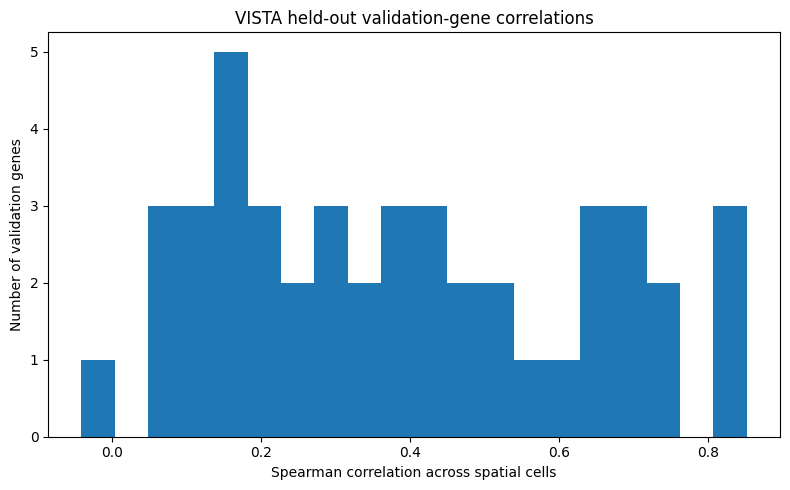

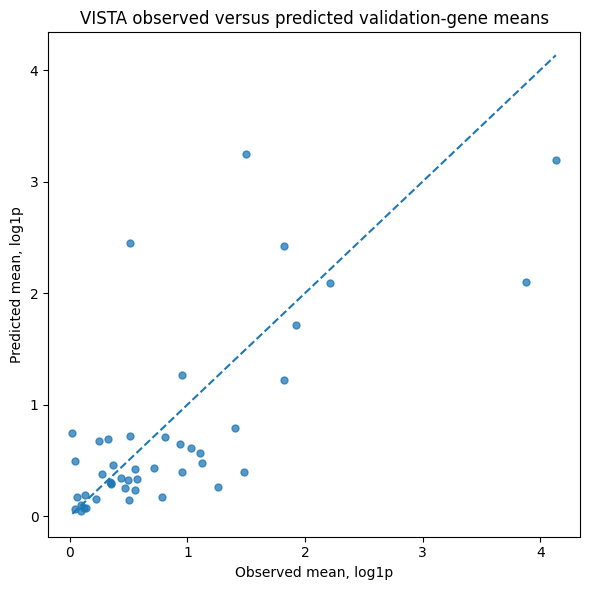

Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/figures/13_vista_validation_spearman_histogram_smoke.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/figures/13_vista_observed_vs_predicted_means_smoke.png


In [18]:
SPEARMAN_FIGURE_PATH = FIGURE_DIR / f"13_vista_validation_spearman_histogram{RUN_SUFFIX}.png"

plt.figure(figsize=(8, 5))
plt.hist(
    gene_metrics["spearman_across_cells"].dropna(),
    bins=20,
)
plt.xlabel("Spearman correlation across spatial cells")
plt.ylabel("Number of validation genes")
plt.title("VISTA held-out validation-gene correlations")
plt.tight_layout()
plt.savefig(SPEARMAN_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.show()
plt.close()


MEAN_FIGURE_PATH = FIGURE_DIR / f"13_vista_observed_vs_predicted_means{RUN_SUFFIX}.png"

plt.figure(figsize=(6, 6))

x = np.log1p(gene_metrics["observed_mean"].clip(lower=0))
y = np.log1p(gene_metrics["predicted_mean"].clip(lower=0))

plt.scatter(x, y, s=25, alpha=0.75)

lower = min(float(x.min()), float(y.min()))
upper = max(float(x.max()), float(y.max()))
plt.plot([lower, upper], [lower, upper], linestyle="--")

plt.xlabel("Observed mean, log1p")
plt.ylabel("Predicted mean, log1p")
plt.title("VISTA observed versus predicted validation-gene means")
plt.tight_layout()
plt.savefig(MEAN_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:")
print(SPEARMAN_FIGURE_PATH)
print(MEAN_FIGURE_PATH)


## 17. Observed-vs-VISTA spatial gene plots

These plots are for advisor presentation.  
The first panel is measured Xenium truth; the second panel is VISTA prediction.

Genes are selected from the 45 validation genes. Priority is given to interpretable marker genes when they are available.


In [19]:
priority_genes = [
    # vascular / mural
    "ACTA2", "CLDN5", "PECAM1", "VWF", "RGS5", "PDGFRB",
    # oligodendrocyte / white matter
    "MBP", "PLP1", "MOG", "MOBP", "MAG",
    # neuronal / layer
    "RORB", "TLE4", "FOXP2", "BCL11B", "CUX2", "CUX1", "SLC17A7", "GAD1", "GAD2",
    # astrocyte / glia
    "AQP4", "GFAP", "ALDH1L1", "SLC1A3",
    # microglia
    "P2RY12", "CX3CR1", "C3",
]

available_priority = [
    gene for gene in priority_genes
    if gene in validation_genes
]

selected_plot_genes = []

for gene in available_priority:
    if gene not in selected_plot_genes:
        selected_plot_genes.append(gene)
    if len(selected_plot_genes) >= N_GENES_TO_PLOT:
        break

if len(selected_plot_genes) < N_GENES_TO_PLOT:
    additional = (
        gene_metrics
        .sort_values(["observed_variance", "observed_nonzero_fraction"], ascending=False)
        ["gene"]
        .astype(str)
        .tolist()
    )

    for gene in additional:
        if gene not in selected_plot_genes:
            selected_plot_genes.append(gene)
        if len(selected_plot_genes) >= N_GENES_TO_PLOT:
            break

print("Selected validation genes for spatial plots:")
print(selected_plot_genes)

plot_gene_table = gene_metrics[
    gene_metrics["gene"].isin(selected_plot_genes)
].copy()

PLOT_GENE_TABLE_PATH = REPORT_DIR / f"13_vista_selected_plot_genes{RUN_SUFFIX}.csv"
plot_gene_table.to_csv(PLOT_GENE_TABLE_PATH, index=False)

display(plot_gene_table)
print("Saved:", PLOT_GENE_TABLE_PATH)


Selected validation genes for spatial plots:
['ACTA2', 'CLDN5', 'MBP', 'GAD1']


,gene,spearman_across_cells,pearson_log1p_across_cells,mae_log1p,rmse_log1p,mae_standardized_log1p,rmse_standardized_log1p,observed_mean,predicted_mean,observed_variance,predicted_variance,observed_nonzero_fraction,predicted_positive_fraction,expression_stratum,expression_stratum_number,mean_expression,detection_fraction
0,ACTA2,0.271318,0.164777,0.450747,0.705125,0.877025,1.292457,1.186625,0.187162,10.690539,0.036497,0.444856,0.999244,S4_high,4,1.186693,0.444789
11,CLDN5,0.369242,0.545196,0.347897,0.521336,0.658696,0.953734,0.770384,0.392812,5.597457,0.282665,0.180019,0.999244,S3_medium,3,0.770292,0.179992
17,GAD1,0.521363,0.820701,0.397125,0.509137,0.458464,0.598831,1.545878,0.904532,25.285381,2.575615,0.219337,0.999244,S4_high,4,1.545744,0.219304
24,MBP,0.699297,0.725671,0.746076,0.924017,0.582512,0.740714,5.196209,10.276532,43.041801,163.116547,0.801690,0.999244,S5_highest,5,5.195215,0.801569


Saved: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/13_vista_selected_plot_genes_smoke.csv


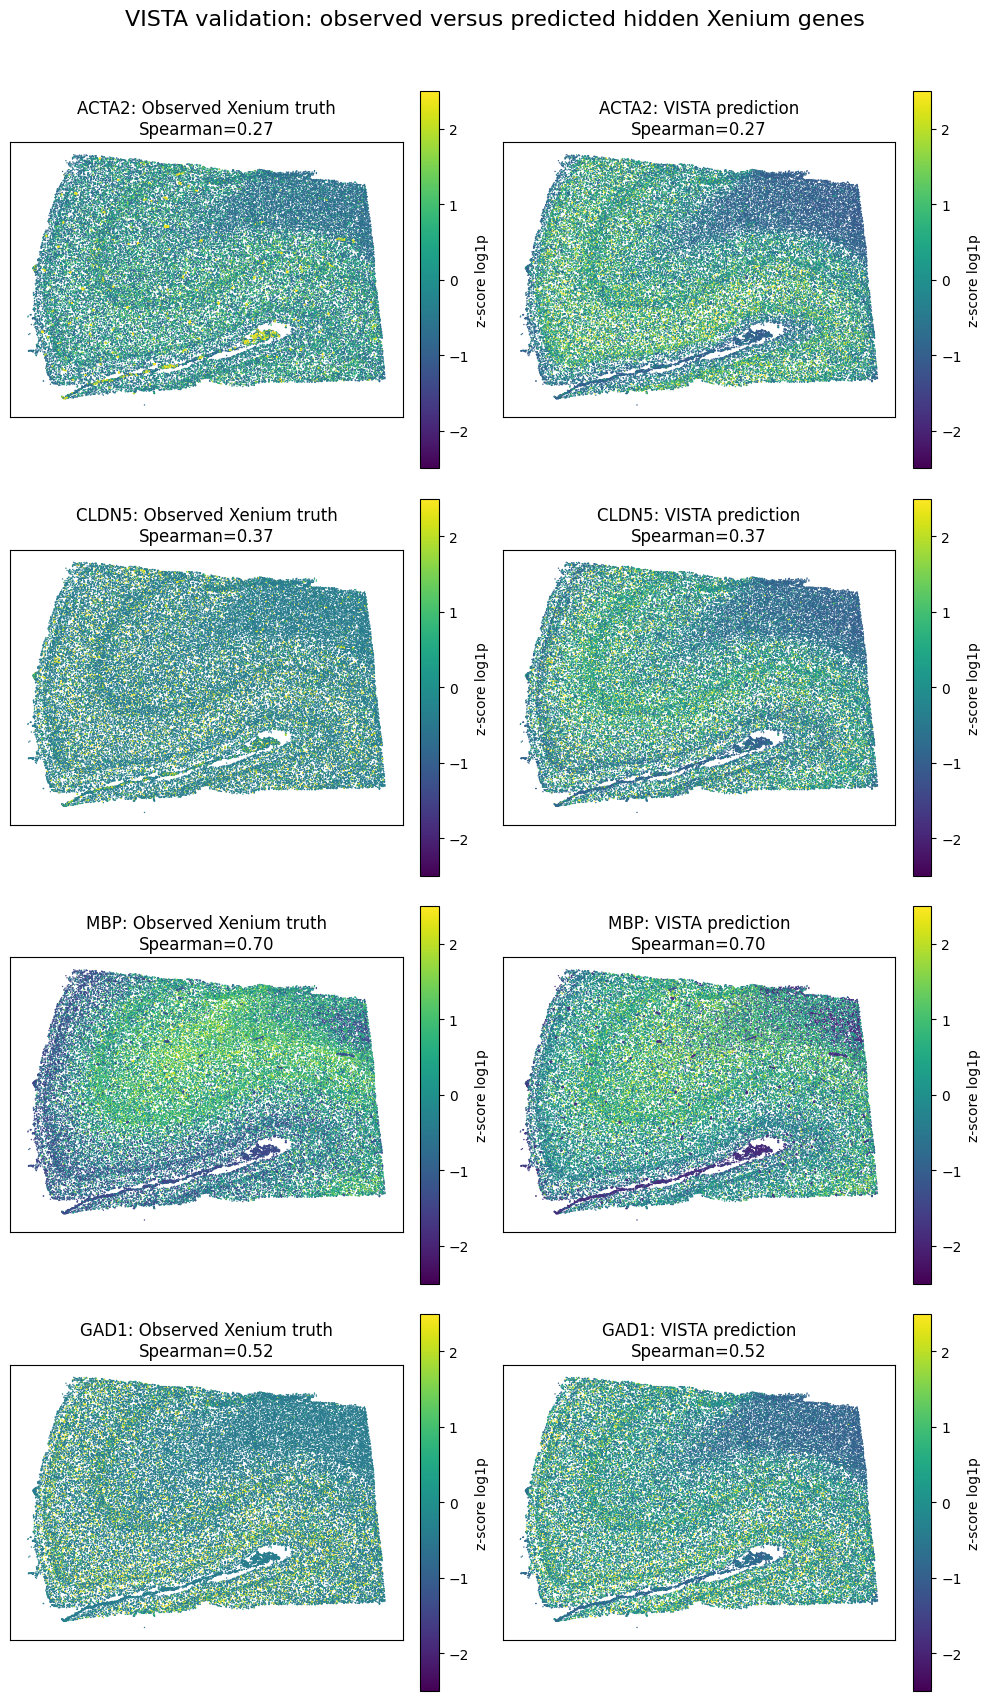

Saved:
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/figures/13_vista_observed_vs_predicted_gene_maps_smoke.png
/users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/figures/13_vista_observed_vs_predicted_gene_maps_smoke.pdf


In [20]:
coordinates = np.asarray(spatial_data_model.obsm["spatial"])
x_coordinate = coordinates[:, 0]
y_coordinate = coordinates[:, 1]

# Composite figure: rows = genes, columns = observed and VISTA.
n_rows = len(selected_plot_genes)
fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(10, 4.2 * n_rows),
    squeeze=False,
)

for row_index, gene in enumerate(selected_plot_genes):
    gene_index = validation_genes.index(gene)

    observed_values = np.log1p(np.clip(observed_validation[:, gene_index], 0, None))
    predicted_values = np.log1p(np.clip(validation_prediction[:, gene_index], 0, None))

    # Standardized scale shows pattern similarity instead of absolute scale.
    observed_plot = np.clip(zscore(observed_values), -2.5, 2.5)
    predicted_plot = np.clip(zscore(predicted_values), -2.5, 2.5)

    panels = [
        ("Observed Xenium truth", observed_plot),
        ("VISTA prediction", predicted_plot),
    ]

    for column_index, (title, values) in enumerate(panels):
        ax = axes[row_index, column_index]

        scatter = ax.scatter(
            x_coordinate,
            y_coordinate,
            c=values,
            s=1,
            linewidths=0,
            rasterized=True,
            vmin=-2.5,
            vmax=2.5,
        )

        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

        metric_value = gene_metrics.loc[
            gene_metrics["gene"] == gene,
            "spearman_across_cells",
        ]

        metric_text = ""
        if len(metric_value) > 0 and np.isfinite(metric_value.iloc[0]):
            metric_text = f"\nSpearman={metric_value.iloc[0]:.2f}"

        ax.set_title(f"{gene}: {title}{metric_text}")

        fig.colorbar(
            scatter,
            ax=ax,
            fraction=0.046,
            pad=0.04,
            label="z-score log1p",
        )

fig.suptitle(
    "VISTA validation: observed versus predicted hidden Xenium genes",
    y=1.01,
    fontsize=16,
)

plt.tight_layout()

COMPOSITE_GENE_FIGURE_PATH = FIGURE_DIR / f"13_vista_observed_vs_predicted_gene_maps{RUN_SUFFIX}.png"
COMPOSITE_GENE_FIGURE_PDF = FIGURE_DIR / f"13_vista_observed_vs_predicted_gene_maps{RUN_SUFFIX}.pdf"

plt.savefig(COMPOSITE_GENE_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.savefig(COMPOSITE_GENE_FIGURE_PDF, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:")
print(COMPOSITE_GENE_FIGURE_PATH)
print(COMPOSITE_GENE_FIGURE_PDF)


## 18. Output inventory

In [21]:
created_outputs = [
    MODEL_DIR,
    RUN_METADATA_PATH,
    PREDICTION_PATH,
    GENE_METRICS_PATH,
    SUMMARY_PATH,
    CELLTYPE_METRICS_PATH,
    LAYER_METRICS_PATH,
    SPEARMAN_FIGURE_PATH,
    MEAN_FIGURE_PATH,
    PLOT_GENE_TABLE_PATH,
    COMPOSITE_GENE_FIGURE_PATH,
    COMPOSITE_GENE_FIGURE_PDF,
]

print("=" * 100)
print("VISTA Br8667 train/validation workflow completed")
print("=" * 100)

for path in created_outputs:
    print(f"{'EXISTS' if path.exists() else 'MISSING'}: {path}")

print("\nBlind-test genes were not loaded or evaluated.")

if RUN_MODE == "smoke":
    print(
        "\nThis was a smoke test. Restart the kernel, set RUN_MODE='full', "
        "and rerun all cells for the scientific validation result."
    )


VISTA Br8667 train/validation workflow completed
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/models/vista_train210_model_smoke
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/12_vista_run_metadata_smoke.csv
EXISTS: /users/mjabin/projects/GeneBridge/data/processed/imputation_beta/Br8667/benchmark/predictions/vista_validation_predictions_45genes_smoke.h5ad
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/13_vista_validation_gene_metrics_smoke.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/13_vista_validation_summary_smoke.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/13_vista_validation_celltype_pseudobulk_smoke.csv
EXISTS: /users/mjabin/projects/GeneBridge/outputs/imputation_beta/Br8667/validation/vista/13_vista_validation_layer_pseudobulk_smoke.csv
EXISTS: /users/mjabin/projects/Gen

## Final benchmark plan

After VISTA validation is complete and method settings are frozen:

1. Combine the 210 training genes and 45 validation genes into a 255-gene spatial input.
2. Retrain VISTA from scratch.
3. Evaluate once on the 45 blind-test genes.
4. For production imputation, train with all 300 measured Xenium genes and impute the unmeasured reference genes.
